# 데이터셋 불러오기

In [272]:
import pandas as pd

df = pd.read_csv('C:/Users/Administrator/Dogyeom(2023.01.01)/KIST_intern/Task1/Control_Nuclear_Spins/initialize13Cspin/testdata_second.csv')
df

,Al,Ap,N,x,z,fun,xx,yy,zz,fev
0,1.124821,1.067854,9.0,1.439310,1.141356,0.040088,0.066757,0.169544,0.997411,809
1,3.722392,0.849740,15.0,1.722010,0.395851,0.011902,0.024930,0.057532,0.998104,616
2,4.535765,1.538114,9.0,1.561517,0.386535,0.010732,0.028713,0.039931,0.999343,702
3,2.544771,0.712238,13.0,2.754948,2.204000,0.030210,0.023434,0.040011,0.995700,388
4,1.915859,0.904068,9.0,2.978654,1.848721,0.023169,0.026655,0.082486,0.997280,672
...,...,...,...,...,...,...,...,...,...,...
1688,4.714067,0.701816,17.0,4.025000,3.220000,0.049429,0.010686,0.153067,0.973855,596
1689,4.967016,0.715827,17.0,3.925000,1.668125,0.045263,0.021046,0.074921,0.964899,501
1690,0.589496,1.553729,9.0,3.589972,0.857017,0.017811,0.118887,0.255017,0.988029,1090
1691,4.496114,1.665006,9.0,1.565901,0.389112,0.010135,0.092295,0.038126,0.997012,631


## 데이터셋 분류

In [273]:
y = df[['N', 'x', 'z']]
y

,N,x,z
0,9.0,1.439310,1.141356
1,15.0,1.722010,0.395851
2,9.0,1.561517,0.386535
3,13.0,2.754948,2.204000
4,9.0,2.978654,1.848721
...,...,...,...
1688,17.0,4.025000,3.220000
1689,17.0,3.925000,1.668125
1690,9.0,3.589972,0.857017
1691,9.0,1.565901,0.389112


In [274]:
X = df[['Al', 'Ap']]
X

,Al,Ap
0,1.124821,1.067854
1,3.722392,0.849740
2,4.535765,1.538114
3,2.544771,0.712238
4,1.915859,0.904068
...,...,...
1688,4.714067,0.701816
1689,4.967016,0.715827
1690,0.589496,1.553729
1691,4.496114,1.665006


## 데이터 학습/테스트 구분

In [275]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.12, random_state=100)

# 학습 모델

## KNN regression

In [276]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor


kn = KNeighborsRegressor(n_neighbors = 10, weights = "distance")
kn.fit(X_train, y_train)

# kn = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=100)
# kn.fit(X_train, y_train)


RandomForestRegressor(max_depth=10, random_state=100)

In [277]:
y_kn_train_pred = kn.predict(X_train)
y_kn_test_pred = kn.predict(X_test)

# Figure

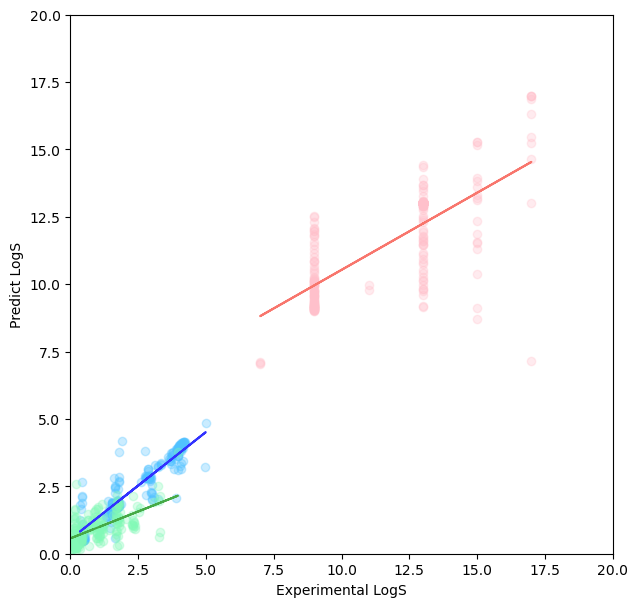

In [278]:
import matplotlib.pyplot as plt
import numpy as np


yn = y_test['N']
ynt = y_kn_test_pred[:,0]

yx = y_test['x']
yxt = y_kn_test_pred[:,1]

yz = y_test['z']
yzt = y_kn_test_pred[:,2]

plt.figure(figsize=(7,7))
plt.scatter(x=yn, y=ynt, c="#FFC0CB" ,alpha=0.3)

plt.scatter(x=yx, y=yxt, c="#50C2FF" ,alpha=0.3)

plt.scatter(x=yz, y=yzt, c="#82F9B7" ,alpha=0.3)

nn = np.polyfit(yn, ynt, 1)
pn = np.poly1d(nn)

xx = np.polyfit(yx, yxt, 1)
px = np.poly1d(xx)

zz = np.polyfit(yz, yzt, 1)
pz = np.poly1d(zz)

plt.plot(yn, pn(yn), '#F8766D')
plt.plot(yx, px(yx), '#3232FF')
plt.plot(yz, pz(yz), '#46AA46')
plt.ylabel('Predict LogS')
plt.xlabel('Experimental LogS')
plt.ylim(0, 20)
plt.xlim(0, 20)
plt.show()

In [279]:
from sklearn.metrics import mean_squared_error, r2_score

# knn_train_mse = mean_squared_error(yn_train, yn_kn_train_pred)
# knn_train_r2 = r2_score(yn_train, yn_kn_train_pred)

knn_test_mse = mean_squared_error(yn, ynt)
knn_test_r2 = r2_score(yn, ynt)

# knx_train_mse = mean_squared_error(yx_train, yx_kn_train_pred)
# knx_train_r2 = r2_score(yx_train, yx_kn_train_pred)

knx_test_mse = mean_squared_error(yx, yxt)
knx_test_r2 = r2_score(yx, yxt)

# knz_train_mse = mean_squared_error(yz_train, yz_kn_train_pred)
# knz_train_r2 = r2_score(yz_train, yz_kn_train_pred)

knz_test_mse = mean_squared_error(yz, yzt)
knz_test_r2 = r2_score(yz, yzt)

In [280]:
# print('KNN MSE (Train): ', knn_train_mse)
# print('KNN R2 (Train): ', knn_train_r2)
print('KNN MSE (Test): ', knn_test_mse)
print('KNN R2 (Test): ', knn_test_r2)
print(' ')
# print('KNX MSE (Train): ', knx_train_mse)
# print('KNX R2 (Train): ', knx_train_r2)
print('KNX MSE (Test): ', knx_test_mse)
print('KNX R2 (Test): ', knx_test_r2)
print(' ')
# print('KNZ MSE (Train): ', knz_train_mse)
# print('KNZ R2 (Train): ', knz_train_r2)
print('KNZ MSE (Test): ', knz_test_mse)
print('KNZ R2 (Test): ', knz_test_r2)

KNN MSE (Test):  3.0500789405345974
KNN R2 (Test):  0.5128788330878984
 
KNX MSE (Test):  0.2793961436798556
KNX R2 (Test):  0.823860629986565
 
KNZ MSE (Test):  0.42805433162246037
KNZ R2 (Test):  0.3604327453956767


# 실험하기

## 기본 설정

In [281]:
from toqito.channels import partial_trace
from qutip import *
from PIL import Image
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from scipy import linalg
import math
import matplotlib.pyplot as plt
from scipy import optimize
import random
from math import *
import pandas as pd
import time
from datetime import datetime as dt                         # 시간을 출력하기 위한 라이브러리  

def UO(B1,B2,a,D1,D2):
    i   = 1j
    gamma = 2*pi*2.8
    D     = 2870
    UA = np.array([[(B2**2+B1**2*cos(a))/(B1**2+B2**2), -i*B1*(e**(-i*D1))*sin(a)/sqrt(B1**2+B2**2), ((-1+cos(a))*B1*B2*(e**(-i*(D1-D2))))/(B1**2+B2**2)],
            [-i*B1*(e**(i*D1))*sin(a)/sqrt(B1**2+B2**2), cos(a), -i*B2*(e**(i*D2))*sin(a)/sqrt(B1**2+B2**2)],
            [((-1+cos(a))*B1*B2*e**(i*(D1-D2)))/(B1**2+B2**2), -i*B2*(e**(-i*D2))*sin(a)/sqrt(B1**2+B2**2), (B1**2+B2**2*cos(a))/(B1**2+B2**2)]])
    return UA

i   = 1j #1j
sx  = 1/sqrt(2)*np.array([[0, 1, 0],[1, 0, 1], [0, 1, 0]])
sy  = 1/sqrt(2)/i*np.array([[0, 1, 0], [-1, 0, 1],[0, -1, 0]])
sz  = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]])
#sz  = [1, 0, 0; 0, -1, 0; 0, 0, 0]
I   = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
#Gellman matrix
Sx  = np.array([[0, 0, 1],[0, 0, 0], [1, 0, 0]])
Sy  = np.array([[0, 0, -i],[0, 0, 0], [i, 0, 0]])
Sz  = np.array([[1, 0, 0],[0, 0, 0], [0, 0, -1]])
# Rotation matrix projected into 2 level system
Sxp  = np.array([[0, 1, 0], [1, 0, 0], [0, 0, 0]])
Sxm  = np.array([[0, 0, 0], [0, 0, 1], [0, 1, 0]])
Syp  = 1/i*np.array([[0, 1, 0], [-1, 0, 0], [0, 0, 0]])
Sym  = 1/i*np.array([[0, 0, 0], [0, 0, 1], [0, -1, 0]])
Szp  = np.array([[1, 0, 0], [0, -1, 0], [0, 0, 0]])
# Pauli basis for 13C nuclear spin
Ix  = 1/2*np.array([[0, 0, 1], [0, 0, 0], [1, 0, 0]])   
Iy  = 1/2/i*np.array([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
Iz  = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]])
 

# Define sweep parameters
Sweep = 1001
N = Sweep
B = 403 #[G] magnetic field

    

# 13C nuclear spin parameters
gammaN = 2*pi*1.071e-3 #[MHz/G]
T = 5; # sweep tau [us]
t = np.linspace(0,T,N)
n = 32; # number of pi pulses

## Define gate operations
# Single Q ms=+1
U090xp = UO(1,0,pi/4,0,0)
U090xmp = UO(1,0,-pi/4,0,0)
U090yp = UO(1,0,pi/4,pi/2,0)
U180yp = UO(1,0,pi/2,pi,0)
U090ymp = UO(1,0,-pi/4,pi/2,0)
U180xp = UO(1,0,pi/2,0,0)
U180xmp = UO(1,0,-pi/2,0,0)

#Single Q ms=-1
U090xm = UO(0,1,pi/4,0,0)
U090xmm = UO(0,1,-pi/4,0,0)
U180xm = UO(0,1,pi/2,0,0)
U180xmm = UO(0,1,pi/2,0,0)
#사용 안됨?

# Define initial state of the system (스핀상태)

irho_p = np.array([[1,0,0],[0,0,0],[0,0,0]]) #;0,0,0;0,0,0]

irho_m = np.array([[0,0,0],[0,0,0],[0,0,1]]) #0,0,0;0,0,1]

irho_z = np.array([[0,0,0],[0,1,0],[0,0,0]]) #0,1,0;0,0,0]

irho_mix = np.array([[1/2,0,0],[0,1/2,0],[0,0,0]])

irho_Z = np.array([[0,0,0],[0,0,0],[0,0,1]])

irho_MIX = np.array([[1/2,0,0],[0,0,0],[0,0,1/2]])

#rotation operator(not use at this code)
def Rx(theta):
    Rx = e**(1j*theta/2*sx)
    return Rx

def Ry(theta):
    Ry = e**(1j*theta/2*sy)
    return Ry

def Rz(phi):
    Rz = e**(1j*phi/2*sz)
    return Rz 

irho = np.kron(irho_p,irho_MIX)

## 수직/수평값 지정

In [282]:
# Al = 2*math.pi*0.3
# Ap = 2*math.pi*0.3

Al    = 2*pi * random.uniform(0.05, 0.8) #[MHz] # A_|| hyperfine term
Ap = 2*pi* random.uniform(0.05, 0.3) #[MHz] # A_per hyperfine term

AAin = pd.DataFrame([[Al, Ap]], columns=['Al', 'Ap'])

In [283]:
AA_predict = kn.predict(AAin)
AAdata = np.zeros((1,3))
AAdata[0][1] = AA_predict[0][0]
AAdata[0][0] = AA_predict[0][1]
AAdata[0][2] = AA_predict[0][2]

AAdata = pd.DataFrame(AAdata, columns=['x', 'N', 'z'])  # x, N, z
AAdata

,x,N,z
0,1.757337,9.998992,0.963827


In [284]:
ham = Al*np.kron(sz,Iz) + Ap*np.kron(sz,Ix) + B*gammaN*np.kron(I,Iz)
eigvals = np.linalg.eigh(ham)[0] # diagonalizing the Hamiltonian 
eigvecs = -1*np.linalg.eigh(ham)[1]
E = np.diag(eigvals)             # exponent of eigenvalues
U_H= eigvecs.conj().T  

xx=0
yy=0
zz=0
vari = AAdata
def problem(vari):
        #for e Ry(pi/2)
        rho1 = np.kron(U090yp,I)@irho@(np.kron(U090yp,I).conj().T)                              # Ry 90도

        #for N Rx(pi/2)
        U_e2=(U_H.conj().T)@(linalg.expm(-i*E* vari[0]/2)@U_H)                                  # for tau/2
        U_e=(U_H.conj().T)@(linalg.expm(-i*E* vari[0])@U_H)                                     # for tau
        rho2=U_e2@rho1@(U_e2.conj().T)                                                          # first tau/2
        for k in range(1,2*math.trunc(vari[1])):                                                # N과 tau를 N개 생성
            rho2 = U_e@np.kron(U180xp,I) @ rho2 @ (np.kron(U180xp,I).conj().T) @ (U_e.conj().T) # N & tau
        rho3 = U_e2 @ np.kron(U180xp,I) @ rho2 @ (np.kron(U180xp,I).conj().T) @ (U_e2.conj().T) # last N & tau/2

        #for e Rx(pi/2)
        rho4 = np.kron(U090xp,I)@rho3@(np.kron(U090xp,I).conj().T)                              # Rx 90도

        #for N Rz(pi/2) //이부분이 Z pulse를 다루고 있다면 N을 따로 분리해야하나?>
        U_e2=(U_H.conj().T)@(linalg.expm(-i*E*vari[2]/2)@U_H)                                   # for tau/2
        U_e=(U_H.conj().T)@(linalg.expm(-i*E*vari[2])@U_H)                                      # for tau/2
        rho5=U_e2@rho4@(U_e2.conj().T)                                                          # first tau/2
        for k in range(1,2*math.trunc(vari[1])):                                                # N과 tau를 N개 생성
            rho5 = U_e@np.kron(U180xp,I) @ rho5 @ (np.kron(U180xp,I).conj().T) @ (U_e.conj().T) # N & tau
        rho6 = U_e2 @ np.kron(U180xp,I) @ rho5 @ (np.kron(U180xp,I).conj().T) @ (U_e2.conj().T) # last N & tau/2

        #for N Rx(pi/2)
        U_e2=(U_H.conj().T)@(linalg.expm(-i*E* vari[0]/2)@U_H)                                  # for tau/2
        U_e=(U_H.conj().T)@(linalg.expm(-i*E* vari[0])@U_H)                                     # for tau
        rho7=U_e2@rho6@(U_e2.conj().T)                                                          # first tau/2
        for k in range(1,2*math.trunc(vari[1])):                                                # N과 tau를 N개 생성
            rho7 = U_e@np.kron(U180xp,I) @ rho7 @ (np.kron(U180xp,I).conj().T) @ (U_e.conj().T) # N & tau
        rho8 = U_e2 @ np.kron(U180xp,I) @ rho7 @ (np.kron(U180xp,I).conj().T) @ (U_e2.conj().T) # last N & tau/2

        # projection&trace
        xob = (np.trace(Sxp@partial_trace(rho8,2))).real # for e spin
        yob = (np.trace(Syp@partial_trace(rho8,2))).real 
        zob = (np.trace(Szp@partial_trace(rho8,2))).real

        xx = (np.trace(Ix@partial_trace(rho8,1))).real # for N spin
        yy = (np.trace(Iy@partial_trace(rho8,1))).real
        zz = (np.trace(Iz@partial_trace(rho8,1))).real
        
        
        # print("rho1 :", partial_trace(rho1,1))
        # print("rho8 :", partial_trace(rho8,1))
        # print(xx,yy,zz)
        # ax.plot(xx,yy,zz,'ro')
        # plt.pause(0.001)
        # cost = ((np.abs(0-xx))**2+(np.abs(0-yy))**2+(np.abs(1-zz))**2)**(1/2)
        cost = np.abs(0-xx) + np.abs(0-yy) + np.abs(1-zz)
        
        return cost

output = []

tolN = 1e-6 #tolerance
tolS = 1e-10 #tolerance

tau = AA_predict[0][1]

In [285]:
bounds = [(0.85*tau, 1.15*tau), (1.0, 17.0), (0.05*tau, 0.8*tau)]

## 결과 확인

In [286]:
res = optimize.minimize(problem, AAdata, bounds=bounds ,method='Nelder-Mead',options={'xtol':tolN,'ftol':tolN}) #Nelder-Mead method

### Nelder-Mead

In [287]:
if((res['x'][1] + 1) % 2 > 1):
    res['x'][1] = math.ceil(res['x'][1])
elif((res['x'][1] + 1) % 2 < 1):
    res['x'][1] = math.floor(res['x'][1])
else:
    res['x'][1] = res['x'][1] + 1
    
    
output.append(res)

output

[ final_simplex: (array([[ 1.68429869, 11.        ,  0.9204715 ],
        [ 1.68429869, 10.67856167,  0.9204715 ],
        [ 1.68429869, 10.67856272,  0.92047151],
        [ 1.68429869, 10.67856229,  0.9204715 ]]), array([0.94967276, 0.94967276, 0.94967276, 0.94967276]))
            fun: 0.949672757825833
        message: 'Optimization terminated successfully.'
           nfev: 194
            nit: 100
         status: 0
        success: True
              x: array([ 1.68429869, 11.        ,  0.9204715 ])]

In [288]:
res4 = optimize.shgo(problem,bounds=bounds,iters=5,options={'xtol':tolS,'ftol':tolS}) #SHGO method

In [289]:
output2 = []
res4['x'][1] = round(res4['x'][1])
output2.append(res4)
output2

[     fun: 0.009409623975810577
     funl: array([0.00940962, 0.01086234, 0.01473772, 0.03003692, 0.0343077 ,
        0.03835535, 0.04164715, 0.04455092, 0.04469959, 0.05366481,
        0.05653248, 0.05683074, 0.05888479, 0.09705064, 0.29508029,
        0.30984653, 0.41881037, 0.43921829, 0.4443153 , 0.45441903,
        0.45773482, 0.49968967, 0.50992717, 0.7472752 , 0.80170044,
        0.87367145, 0.8822878 , 0.89517407, 0.90101067, 0.9074733 ,
        0.91473907, 0.92194637, 0.93192893, 0.93839824, 0.94357497,
        0.95359344, 0.95739947, 0.95741049, 0.96681484, 0.96784955,
        0.96918513, 0.98351059, 0.98424563, 0.98483789, 0.98562859,
        0.985683  , 0.98595447, 0.98760091, 0.98862132, 0.98878325,
        0.98883967, 0.98961302, 0.98972351, 0.99163024, 0.99178984,
        0.99209412, 0.9925443 , 0.99314882, 0.99375985, 0.99379191,
        0.99461259, 0.99531994, 0.99606767, 0.996213  , 0.99633543,
        0.99666064, 0.99679423, 0.99684606, 0.99703413, 0.99736909,
      

In [290]:
print(res['x'])
print(" ")
print(res4['x'])

[ 1.68429869 11.          0.9204715 ]
 
[ 1.53461708 10.          0.82114104]
